# AIM : Bike-Sharing Demand Prediction Using Linear Regression

Name : Vansh Sachdeva

Roll No: BTECH/25174/24

BTech Branch : AI

SEM : V

# Problem Statement :

 city bike-sharing company needs to predict the number of bicycles that will be
rented at a particular time. Accurate demand prediction can help the company:

• Allocate bicycles efficiently

• Reduce shortages

• Improve customer satisfaction

• Plan redistribution

• Optimize operational resources

Develop a bike-sharing demand prediction system using Linear Regression.

In [2]:
#connecting the drive for the data set
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#to find the hour.csv path
!find /content/drive/MyDrive -iname "*hour*"

/content/drive/MyDrive/BikeSharing /hour.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/BikeSharing /hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


To Understand the data set :-

In [8]:
print(f"shape :- \n{df.shape}")
print(f"Columns :-\n{df.columns}")
print(f"data type :- \n{df.dtypes}")
print(f"is null: {df.isnull().sum()}")
df.describe()

shape :- 
(17379, 17)
Columns :-
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')
data type :- 
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object
is null: instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


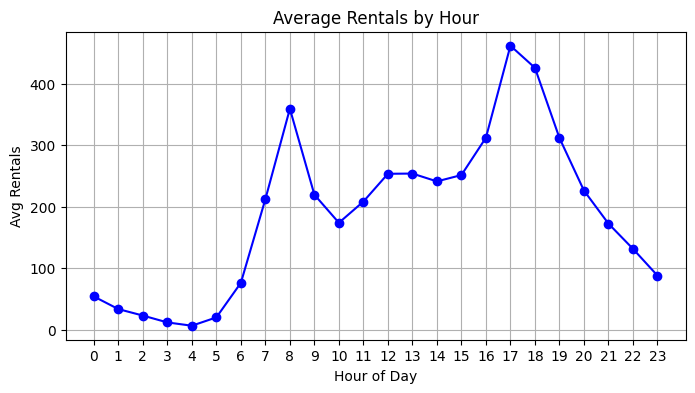

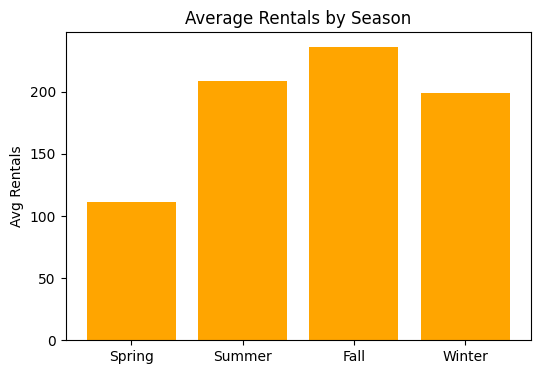

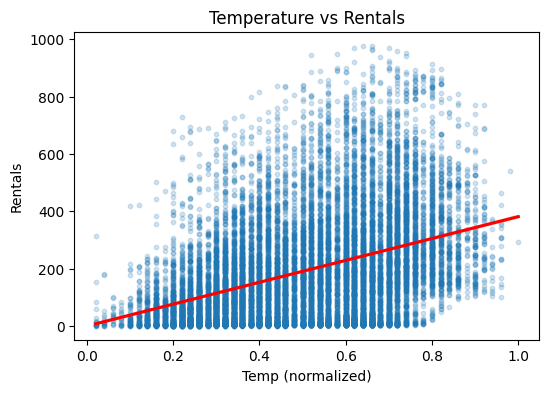

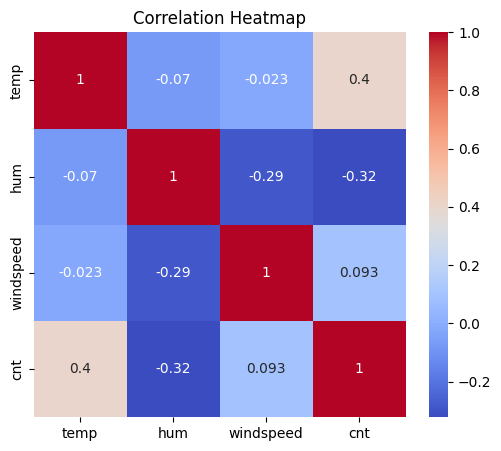

In [9]:
import seaborn as sns

# Hourly demand pattern
plt.figure(figsize=(8,4))
hourly_avg = df.groupby('hr')['cnt'].mean()
plt.plot(hourly_avg, marker='o', color='blue')
plt.title('Average Rentals by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Rentals')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

# Season-wise demand
plt.figure(figsize=(6,4))
season_avg = df.groupby('season')['cnt'].mean()
season_names = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
plt.bar([season_names[s] for s in season_avg.index], season_avg.values, color='orange')
plt.title('Average Rentals by Season')
plt.ylabel('Avg Rentals')
plt.show()

# Temperature vs Rentals (scatter with trend line)
plt.figure(figsize=(6,4))
sns.regplot(x=df['temp'], y=df['cnt'], scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'red'})
plt.title('Temperature vs Rentals')
plt.xlabel('Temp (normalized)')
plt.ylabel('Rentals')
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df[['temp','hum','windspeed','cnt']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [10]:
#simple linear regression using sk-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[['temp']]
y = df['cnt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept: ", model.intercept_)
print("Slope: ", model.coef_[0])

y_pred = model.predict(X_test)

print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2: ", r2_score(y_test, y_pred))

Intercept:  1.1147645659039824
Slope:  380.90819317169706
MAE:  123.1528738977561
MSE:  26363.544525542813
RMSE:  162.36854536991706
R2:  0.16743401039637895


# Gradient Descent — cost vs iterations graph

GD intercept: 1.1147645659167622 
GD slope: 380.9081931716724


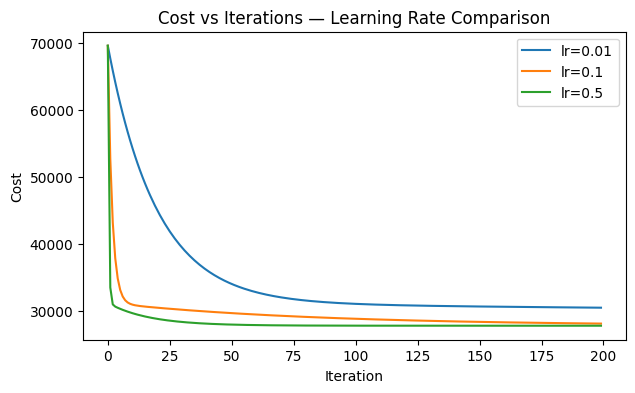

In [13]:
def gradient_descent(x, y, lr, epochs):
    b0, b1 = 0, 0
    n = len(x)
    cost_list = []
    for i in range(epochs):
        y_pred = b0 + b1*x
        cost = (1/n) * sum((y - y_pred)**2)
        cost_list.append(cost)
        d_b0 = (-2/n) * sum(y - y_pred)
        d_b1 = (-2/n) * sum(x * (y - y_pred))
        b0 = b0 - lr*d_b0
        b1 = b1 - lr*d_b1
    return b0, b1, cost_list

x = X_train['temp'].values
y = y_train.values

b0, b1, cost_list = gradient_descent(x, y, lr=0.5, epochs=1000)
print("GD intercept:", b0, "\nGD slope:", b1)
plt.figure(figsize=(7,4))
learning_rates = [0.01, 0.1, 0.5]
for lr in learning_rates:
    b0, b1, cost_list = gradient_descent(x, y, lr=lr, epochs=200)
    plt.plot(cost_list, label=f'lr={lr}')
plt.title('Cost vs Iterations — Learning Rate Comparison')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()
plt.show()

# Multiple Linear Regression

In [14]:
features = ['temp','hum','windspeed','hr','season','workingday','weathersit']
X_multi = df[features]
y_multi = df['cnt']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)
print("MAE:", mean_absolute_error(y_test2, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test2, y_pred2)))
print("R2:", r2_score(y_test2, y_pred2))

MAE: 106.96115738373418
RMSE: 144.24714828937454
R2: 0.3429032211667117


# Actual vs Predicted plot

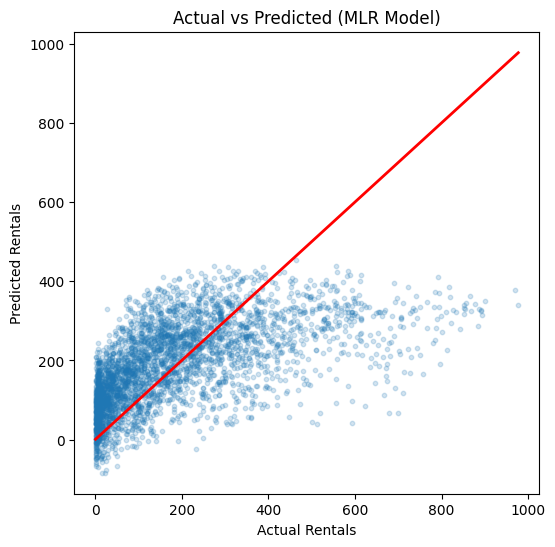

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(y_test2, y_pred2, alpha=0.2, s=10)
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], color='red', linewidth=2)
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')
plt.title('Actual vs Predicted (MLR Model)')
plt.show()

# Comparison b/w SLR and MLR

In [17]:
results = pd.DataFrame({
    'Model': ['SLR', 'MLR'],
    'MAE': [mean_absolute_error(y_test, y_pred), mean_absolute_error(y_test2, y_pred2)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred)), np.sqrt(mean_squared_error(y_test2, y_pred2))],
    'R2': [r2_score(y_test, y_pred), r2_score(y_test2, y_pred2)]
})
results


,Model,MAE,RMSE,R2
0,SLR,123.152874,162.368545,0.167434
1,MLR,106.961157,144.247148,0.342903


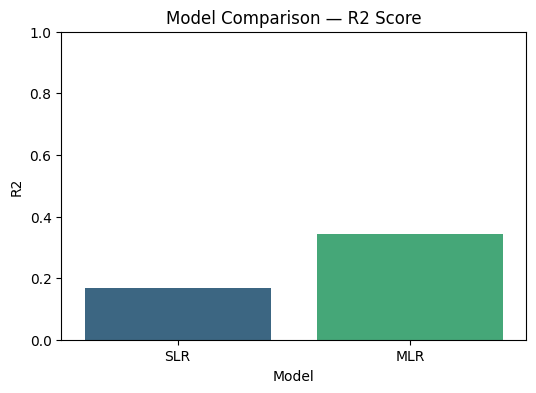

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='R2', data=results, hue='Model', palette='viridis', legend=False)
plt.title('Model Comparison — R2 Score')
plt.ylim(0, 1)
plt.show()